In [1]:
# =========================
# COLAB SETUP & FILE UPLOAD
# =========================
import sys, os, io, textwrap, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Colab-specific upload helper
try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    IN_COLAB = False

print("In Colab:", IN_COLAB)

# Upload prompt (only needed once). If you've already uploaded, you can skip this cell.
if IN_COLAB:
    print("Upload files: ecb_policy_rates.csv, estr.csv (and optionally estr_liquidity.csv)")
    uploaded = files.upload()  # choose your CSVs from your computer


In Colab: False


In [2]:
# =========================
# PATHS (Colab current dir)
# =========================
POLICY_PATH = "ecb_policy_rates.csv"    # required
ESTR_PATH   = "estr.csv"                # required
ESTR_LIQUID = "estr_liquidity.csv"      # optional
OUTPUT_DIR  = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [3]:
def _normalize_cols(df):
    # strip BOM/whitespace, keep exact string content
    df.columns = [c.strip().replace("\ufeff","") for c in df.columns]
    return df

def _coalesce_date_columns(df):
    # Accept any of these as the source of 'date'
    date_candidates = [c for c in df.columns if c.lower() in {"date","time period","timeperiod","time_period","date/time"} or c in {"DATE","Time period","TIME PERIOD"}]
    if not date_candidates:
        return df
    # build one unified 'date' from the first non-null across candidates
    dt = None
    for c in date_candidates:
        col = pd.to_datetime(df[c], errors="coerce")
        dt = col if dt is None else dt.fillna(col)
    df["date"] = dt
    # drop original date-like columns except 'date'
    for c in date_candidates:
        if c != "date":
            df = df.drop(columns=c, errors="ignore")
    return df

def _try_rename_policy_columns(df):
    # Map common ECB long labels to short names
    rename_map = {
        # policy rates (various ECB wordings)
        "Deposit facility": "ecb_deposit_rate",
        "Deposit facility (DFR)": "ecb_deposit_rate",
        "Deposit facility - date of changes (raw data) - Level (FM.B.U2.EUR.4F.KR.DFR.LEV)": "ecb_deposit_rate",

        "Marginal lending facility": "ecb_marginal_lending_rate",
        "Marginal lending facility (MLF)": "ecb_marginal_lending_rate",
        "Marginal lending facility - date of changes (raw data) - Level (FM.B.U2.EUR.4F.KR.MLFR.LEV)": "ecb_marginal_lending_rate",

        "Main refinancing operations (fixed rate)": "ecb_mro_rate",
        "Main refinancing operations – fixed rate tenders (fixed rate)": "ecb_mro_rate",
        "Main refinancing operations - fixed rate tenders (fixed rate) (date of changes) - Level (FM.B.U2.EUR.4F.KR.MRR_FR.LEV)": "ecb_mro_rate",
    }
    return df.rename(columns=rename_map)

def read_policy(path=POLICY_PATH):
    # read without parse_dates first, because header might not be 'date' yet
    df = pd.read_csv(path, sep=None, engine="python")
    df = _normalize_cols(df)
    df = _coalesce_date_columns(df)
    df = _try_rename_policy_columns(df)

    need = {"date","ecb_deposit_rate","ecb_mro_rate","ecb_marginal_lending_rate"}
    missing = need - set(df.columns)
    if missing:
        raise ValueError(f"Policy CSV missing columns: {missing}. Found: {list(df.columns)}")

    # parse date now that 'date' exists
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.dropna(subset=["date"]).sort_values("date").drop_duplicates("date")

    # standardize to business-day frequency & forward-fill (ECB 'date of changes' series)
    df = df.set_index("date").asfreq("B").ffill().reset_index()
    return df

def read_estr(path=ESTR_PATH):
    # read without parse_dates first
    df = pd.read_csv(path, sep=None, engine="python")
    df = _normalize_cols(df)
    df = _coalesce_date_columns(df)
    # map common €STR labels
    df = df.rename(columns={
        "€STR":"estr_rate",
        "estr":"estr_rate",
        "Euro short-term rate - Volume-weighted trimmed mean rate (EST.B.EU000A2X2A25.WT)": "estr_rate"
    })
    if "estr_rate" not in df.columns or "date" not in df.columns:
        raise ValueError(f"€STR CSV must have 'date' and 'estr_rate'. Found: {list(df.columns)}")

    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.dropna(subset=["date"]).sort_values("date").drop_duplicates("date")
    # align to business days and fill minor gaps
    df = df.set_index("date").asfreq("B").interpolate(method="time").reset_index()
    return df

def read_estr_liquidity(path=ESTR_LIQUID):
    if not os.path.isfile(path):
        return None
    df = pd.read_csv(path, sep=None, engine="python")
    df = _normalize_cols(df)
    df = _coalesce_date_columns(df)
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df = df.dropna(subset=["date"]).sort_values("date").drop_duplicates("date")
    return df

# Load
policy = read_policy()
estr   = read_estr()
estr_l = read_estr_liquidity()

policy.head(), estr.head()

(        date  ecb_deposit_rate  ecb_marginal_lending_rate  ecb_mro_rate
 0 1999-01-01              2.00                       4.50           3.0
 1 1999-01-04              2.75                       3.25           3.0
 2 1999-01-05              2.75                       3.25           3.0
 3 1999-01-06              2.75                       3.25           3.0
 4 1999-01-07              2.75                       3.25           3.0,
         date  \
 0 2019-10-01   
 1 2019-10-02   
 2 2019-10-03   
 3 2019-10-04   
 4 2019-10-07   
 
    Euro short-term rate - Rate at 75th percentile of volume (EST.B.EU000A2X2A25.R75)  \
 0                                              -0.53                                   
 1                                              -0.54                                   
 2                                              -0.54                                   
 3                                              -0.54                                   
 4          

In [4]:
# =========================
# MERGE & FEATURE ENGINEERING
# =========================
merged = pd.merge_asof(estr.sort_values("date"),
                       policy.sort_values("date"),
                       on="date")

# Core spread: €STR - Deposit Facility (the policy floor)
merged["estr_minus_deposit"] = merged["estr_rate"] - merged["ecb_deposit_rate"]

# Daily changes (first differences) for event/regression
for col in ["estr_rate","ecb_deposit_rate","ecb_mro_rate","ecb_marginal_lending_rate"]:
    merged[f"d_{col}"] = merged[col].diff()

print("Merged rows:", len(merged))
merged.to_csv(os.path.join(OUTPUT_DIR, "merged_data.csv"), index=False)
merged.tail()


Merged rows: 1576


,date,Euro short-term rate - Rate at 75th percentile of volume (EST.B.EU000A2X2A25.R75),Euro short-term rate - Total volume (EST.B.EU000A2X2A25.TT),estr_rate,ecb_deposit_rate,ecb_marginal_lending_rate,ecb_mro_rate,estr_minus_deposit,d_estr_rate,d_ecb_deposit_rate,d_ecb_mro_rate,d_ecb_marginal_lending_rate
1571,2025-10-08,1.95,62497.0,1.924,2.0,2.4,2.15,-0.076,-0.002,0.0,0.0,0.0
1572,2025-10-09,1.95,62467.0,1.927,2.0,2.4,2.15,-0.073,0.003,0.0,0.0,0.0
1573,2025-10-10,1.95,65040.0,1.926,2.0,2.4,2.15,-0.074,-0.001,0.0,0.0,0.0
1574,2025-10-13,1.95,69968.0,1.926,2.0,2.4,2.15,-0.074,0.000,0.0,0.0,0.0
1575,2025-10-14,1.95,67099.0,1.927,2.0,2.4,2.15,-0.073,0.001,0.0,0.0,0.0


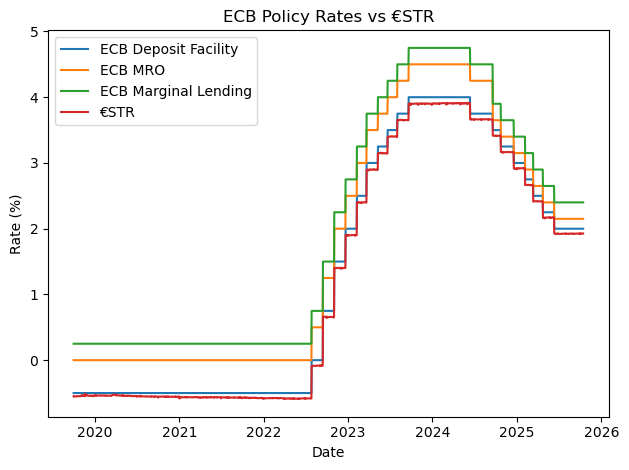

In [5]:
# =========================
# CHART 1: POLICY vs €STR
# =========================
plt.figure()
plt.plot(merged["date"], merged["ecb_deposit_rate"], label="ECB Deposit Facility")
plt.plot(merged["date"], merged["ecb_mro_rate"], label="ECB MRO")
plt.plot(merged["date"], merged["ecb_marginal_lending_rate"], label="ECB Marginal Lending")
plt.plot(merged["date"], merged["estr_rate"], label="€STR")
plt.title("ECB Policy Rates vs €STR")
plt.xlabel("Date"); plt.ylabel("Rate (%)"); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "policy_vs_estr.png"), dpi=160)
plt.show()


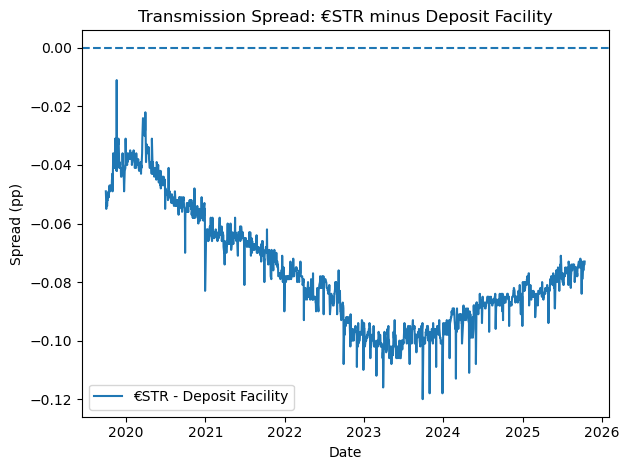

In [6]:
# =========================
# CHART 2: €STR - DEPOSIT SPREAD
# =========================
plt.figure()
plt.plot(merged["date"], merged["estr_minus_deposit"], label="€STR - Deposit Facility")
plt.axhline(0.0, linestyle="--")
plt.title("Transmission Spread: €STR minus Deposit Facility")
plt.xlabel("Date"); plt.ylabel("Spread (pp)"); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "estr_deposit_spread.png"), dpi=160)
plt.show()


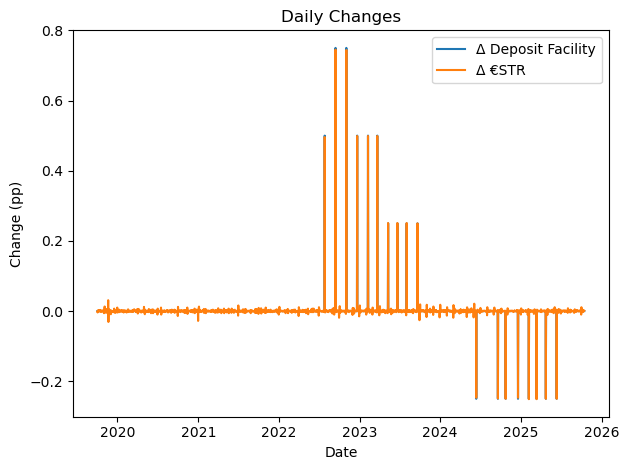

In [7]:
# =========================
# CHART 3: DAILY CHANGES
# =========================
plt.figure()
plt.plot(merged["date"], merged["d_ecb_deposit_rate"], label="Δ Deposit Facility")
plt.plot(merged["date"], merged["d_estr_rate"], label="Δ €STR")
plt.title("Daily Changes")
plt.xlabel("Date"); plt.ylabel("Change (pp)"); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "daily_changes.png"), dpi=160)
plt.show()


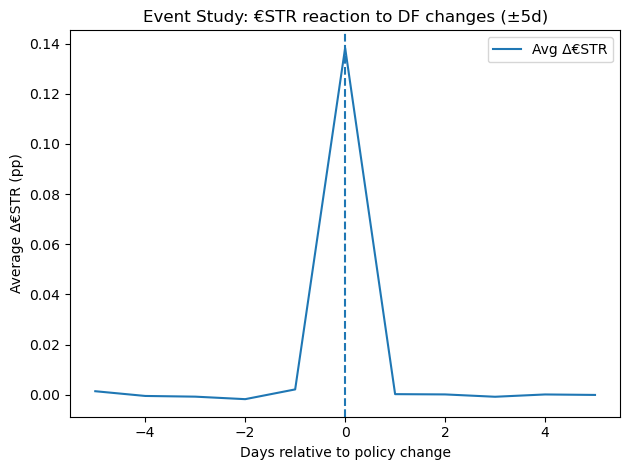

In [8]:
# =========================
# EVENT STUDY: RESPONSE OF €STR
# Around deposit-rate changes (±5 business days)
# =========================
chg_days = merged.loc[merged["d_ecb_deposit_rate"].abs() > 1e-12, "date"].tolist()
wins = []
for d in chg_days:
    idx = merged.index[merged["date"] == d][0]
    for k in range(-5, 6):
        j = idx + k
        if 0 <= j < len(merged):
            wins.append({"k":k, "d_estr": merged.loc[j, "d_estr_rate"]})
event_df = pd.DataFrame(wins)
avg_event = event_df.groupby("k").mean().reset_index()

plt.figure()
plt.plot(avg_event["k"], avg_event["d_estr"], label="Avg Δ€STR")
plt.axvline(0, linestyle="--"); plt.title("Event Study: €STR reaction to DF changes (±5d)")
plt.xlabel("Days relative to policy change"); plt.ylabel("Average Δ€STR (pp)")
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "event_study.png"), dpi=160)
plt.show()


In [9]:
# =========================
# SIMPLE REGRESSION: Δ€STR ~ ΔDeposit
# =========================
x = merged["d_ecb_deposit_rate"].fillna(0)
y = merged["d_estr_rate"].fillna(0)

# closed-form OLS slope (beta)
x_mean, y_mean = x.mean(), y.mean()
cov_xy = ((x - x_mean) * (y - y_mean)).mean()
var_x  = ((x - x_mean)**2).mean()
beta = cov_xy / var_x if var_x > 1e-12 else np.nan
corr = np.corrcoef(x, y)[0,1]

print(f"Beta (Δ€STR on ΔDeposit): {beta:.3f}")
print(f"Corr(Δ€STR, ΔDeposit):    {corr:.3f}")

# Save quick stats
with open(os.path.join(OUTPUT_DIR, "quick_stats.txt"), "w") as f:
    f.write(f"Beta (Δ€STR on ΔDeposit): {beta:.3f}\n")
    f.write(f"Corr(Δ€STR, ΔDeposit):    {corr:.3f}\n")


Beta (Δ€STR on ΔDeposit): 0.996
Corr(Δ€STR, ΔDeposit):    0.996


In [10]:
# =========================
# For indepth interpretation refer to the ppt like  - https://docs.google.com/presentation/d/1xwgTamCvrpRG7FvVhG90cJqKkGuxqdFeyLVh3cM7FF0/edit?usp=sharing
# =========================

